In [1]:
import pandas as pd
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB
None


In [2]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0,5,12,17],
                         labels=['Toddler','Child','Teen'])

In [3]:
df['Screen_Time_Category'] = pd.cut(df['Avg_Daily_Screen_Time_hr'],
                                    bins=[0,2,4,6,24],
                                    labels=['Low','Moderate','High','Very High'])

In [4]:
df['Device_Type_Category'] = df['Primary_Device'].replace({
    'Smartphone':'Mobile/Tablet',
    'Tablet':'Mobile/Tablet',
    'Laptop':'Laptop/PC',
    'Desktop':'Laptop/PC',
    'Television':'TV',
    'Gaming Console':'Gaming'
})

In [5]:
df['Urban_Rural_Score'] = df['Urban_or_Rural'].map({'Urban':1, 'Rural':0})

In [7]:
def st_status(x):
    if x <= 2:
        return 'Healthy'
    elif x <= 4:
        return 'Moderate'
    else:
        return 'Excessive'

df['Screen_Time_Status'] = df['Avg_Daily_Screen_Time_hr'].apply(st_status)

In [8]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group,Screen_Time_Category,Device_Type_Category,Urban_Rural_Score,Screen_Time_Status
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Moderate,Mobile/Tablet,1,Moderate
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,High,Laptop/PC,1,Excessive
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,NaN,Moderate,TV,1,Moderate
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,Teen,Low,Laptop/PC,1,Healthy
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,High,Mobile/Tablet,1,Excessive


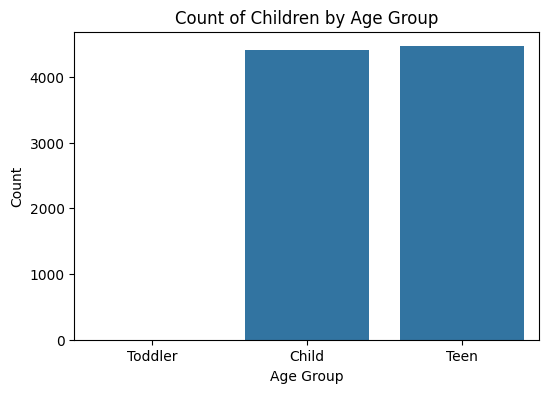

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Age_Group')
plt.title("Count of Children by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

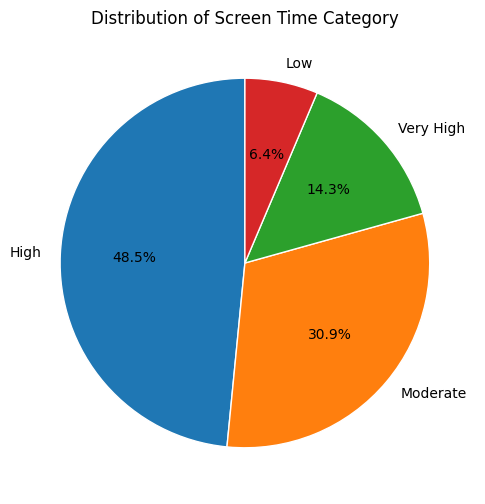

In [10]:
plt.figure(figsize=(6,6))
df['Screen_Time_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
plt.title("Distribution of Screen Time Category")
plt.ylabel("")
plt.show()

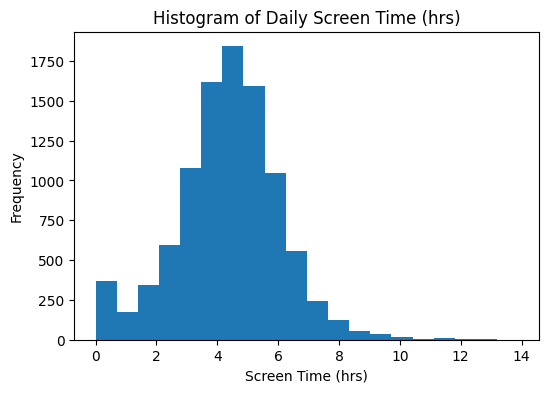

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df['Avg_Daily_Screen_Time_hr'], bins=20)
plt.title("Histogram of Daily Screen Time (hrs)")
plt.xlabel("Screen Time (hrs)")
plt.ylabel("Frequency")
plt.show()

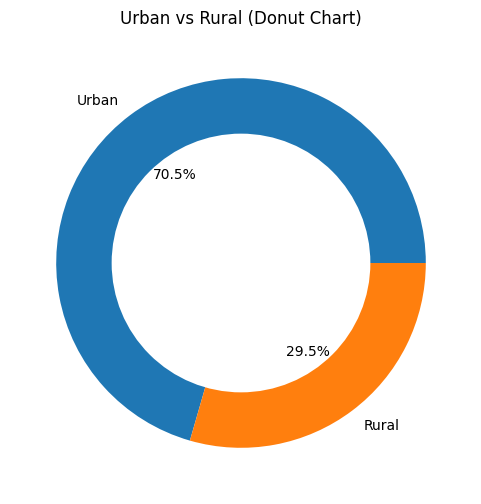

In [12]:
plt.figure(figsize=(6,6))
sizes = df['Urban_or_Rural'].value_counts()
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%')
center = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center)
plt.title("Urban vs Rural (Donut Chart)")
plt.show()

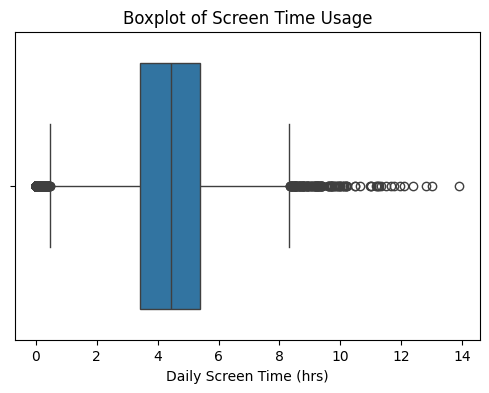

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Avg_Daily_Screen_Time_hr'])
plt.title("Boxplot of Screen Time Usage")
plt.xlabel("Daily Screen Time (hrs)")
plt.show()

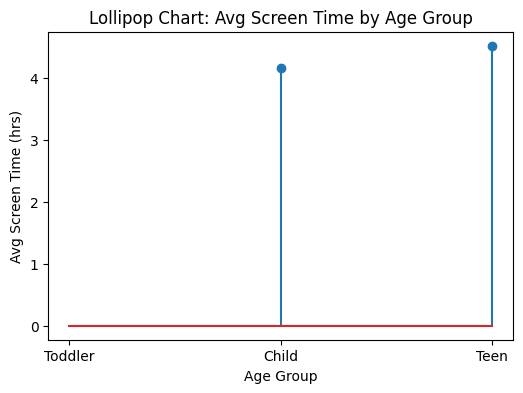

In [15]:
group_mean = df.groupby('Age_Group', observed=False)['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,4))
plt.stem(group_mean.index, group_mean.values)
plt.title("Lollipop Chart: Avg Screen Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()

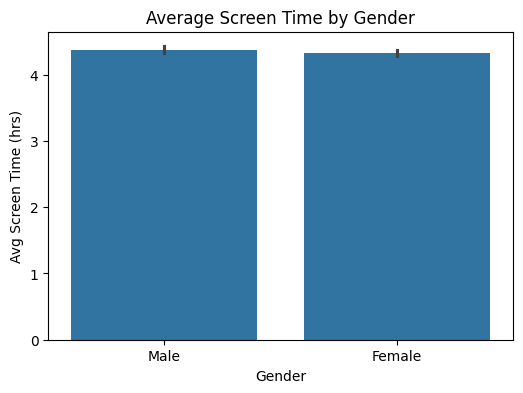

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr')
plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()

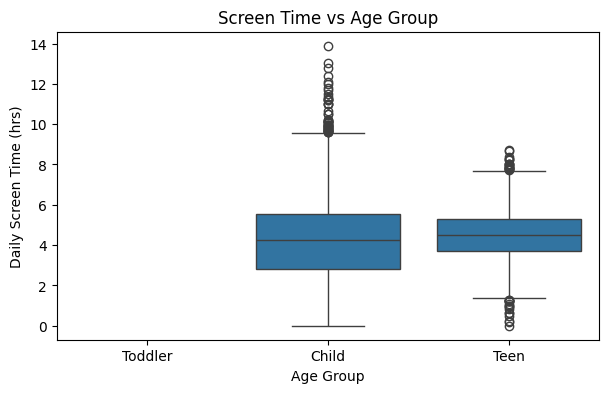

In [17]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Age_Group', y='Avg_Daily_Screen_Time_hr')
plt.title("Screen Time vs Age Group")
plt.xlabel("Age Group")
plt.ylabel("Daily Screen Time (hrs)")
plt.show()

/tmp/ipython-input-364/36143371.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_values = df.groupby('Age_Group')['Avg_Daily_Screen_Time_hr'].median()


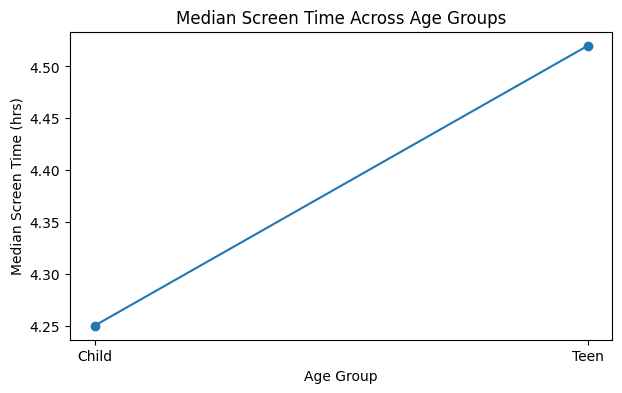

In [18]:
median_values = df.groupby('Age_Group')['Avg_Daily_Screen_Time_hr'].median()

plt.figure(figsize=(7,4))
plt.plot(median_values.index, median_values.values, marker='o')
plt.title("Median Screen Time Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Median Screen Time (hrs)")
plt.show()

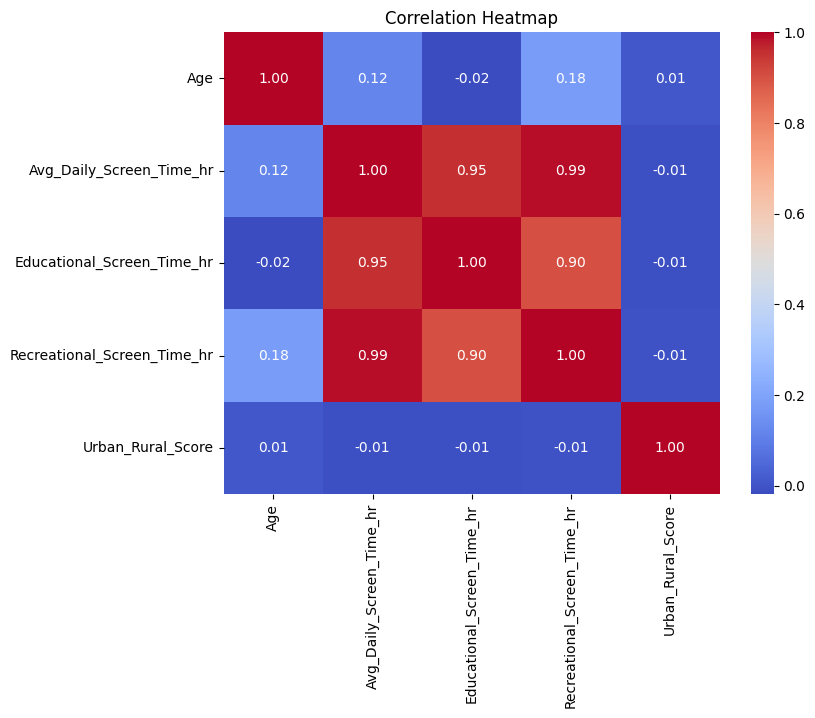

In [36]:
df['Educational_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * (df['Educational_to_Recreational_Ratio'] / (1 + df['Educational_to_Recreational_Ratio']))
df['Recreational_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] - df['Educational_Screen_Time_hr']

plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Age','Avg_Daily_Screen_Time_hr','Educational_Screen_Time_hr',
        'Recreational_Screen_Time_hr','Urban_Rural_Score']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

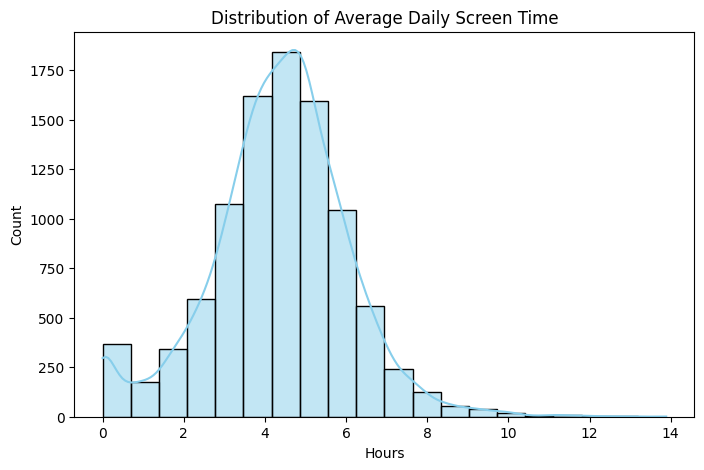

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Avg_Daily_Screen_Time_hr'],
    bins=20,
    kde=True,
    color='skyblue'
)
plt.title("Distribution of Average Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

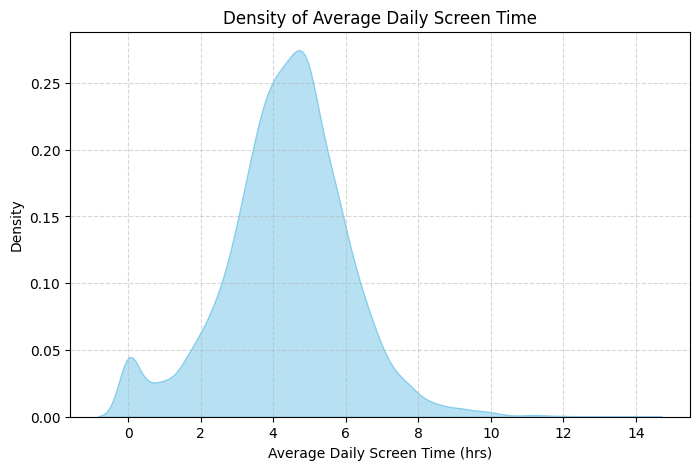

In [35]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='Avg_Daily_Screen_Time_hr',
    fill=True,
    color='skyblue',
    alpha=0.6
)
plt.title("Density of Average Daily Screen Time")
plt.xlabel("Average Daily Screen Time (hrs)")
plt.ylabel("Density")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

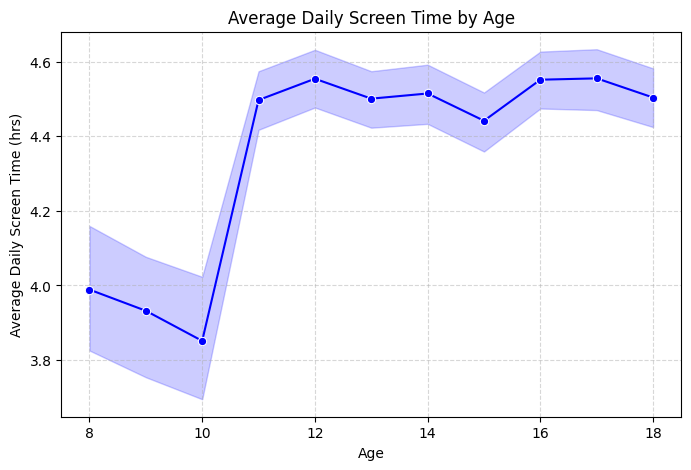

In [34]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x='Age',
    y='Avg_Daily_Screen_Time_hr',
    marker='o',
    color='blue'
)
plt.title("Average Daily Screen Time by Age")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()